이번 미션에서는  모델을 활용하여 FashionMNIST 데이터셋의 각 패션 아이템(예: 티셔츠, 바지, 스니커즈 등)을 조건부로 생성하는 작업을 수행합니다. 

각 클래스에 해당하는 이미지를 생성하는 cGAN (Conditional GAN) 모델을 직접 설계하고 학습시켜 보세요.

### 기본 설정

In [23]:
import torch
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import gc
import os


# 시각화 관련 설정
try:
    plt.rcParams['font.family'] = 'Apple SD Gothic Neo'
except:
    try:
        plt.rcParams['font.family'] = 'NanumGothic'
    except:
        plt.rcParams['font.family'] = 'AppleGothic'

plt.rcParams['axes.unicode_minus'] = False
fm._load_fontmanager(try_read_cache=False)


# 디바이스 설정
if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    DEVICE = torch.device("mps") # 맥 GPU
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda:0") # 윈도우 GPU
else:
    DEVICE = torch.device("cpu") # CPU


# 캐시 지우기 함수 생성
def clean_cache():
    gc.collect()
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        torch.mps.empty_cache()
    elif torch.cuda.is_available():
        torch.cuda.empty_cache()

# MallocStackLogging 에러 출력 방지
os.environ.pop("MallocStackLogging", None)
os.environ.pop("MallocStackLoggingNoCompact", None)
os.environ.pop("DYLD_INSERT_LIBRARIES", None)


# 로그
import logging

def init_logger() -> logging.Logger:
    logging.basicConfig(
        format="%(asctime)s [%(levelname)s] (%(filename)s:%(lineno)d) - %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S",
        level=logging.INFO,
        encoding="utf-8",
    )
    return logging.getLogger("")

logger = init_logger()

Matplotlib is building the font cache; this may take a moment.


## 1. 데이터 파악 및 오류 확인

In [24]:
import torchvision

TRAIN_DATASET = torchvision.datasets.FashionMNIST(root="./data", train=True, download=True)
TEST_DATASET = torchvision.datasets.FashionMNIST(root="./data", train=False, download=True)

In [124]:
print(f"[데이터 개수]")
print(f"· 학습 데이터: {len(TRAIN_DATASET)}개")
print(f"· 테스트 데이터: {len(TEST_DATASET)}개")

print(f"\n[데이터 형식]")
print(f"· 학습 데이터: {TRAIN_DATASET[0]}")
print(f"· 테스트 데이터: {TEST_DATASET[0]}")

train_size_set = set()
for data in TRAIN_DATASET:
    train_size_set.add(data[0].size)

test_size_set = set()
for data in TEST_DATASET:
    test_size_set.add(data[0].size)

print(f"\n[사이즈 구성]")
print(f"· 학습 데이터: {train_size_set}")
print(f"· 테스트 데이터: {test_size_set}")

[데이터 개수]
· 학습 데이터: 60000개
· 테스트 데이터: 10000개

[데이터 형식]
· 학습 데이터: (<PIL.Image.Image image mode=L size=28x28 at 0x11C0C3CD0>, 9)
· 테스트 데이터: (<PIL.Image.Image image mode=L size=28x28 at 0x11C0C3DC0>, 9)

[사이즈 구성]
· 학습 데이터: {(28, 28)}
· 테스트 데이터: {(28, 28)}


데이터는 흑백의 28*28 사이즈 이미지와 클래스로 구성되어 있다.

In [88]:
TRAIN_CLASS_DICT = {i: class_name for i, class_name in enumerate(TRAIN_DATASET.classes)}
TEST_CLASS_DICT = {i: class_name for i, class_name in enumerate(TEST_DATASET.classes)}

print(f"[클래스 형식]")
print(f"· 학습 데이터: {TRAIN_CLASS_DICT}")
print(f"· 테스트 데이터: {TEST_CLASS_DICT}")

print(f"\n[클래스 개수]")
train_count_list = [0 for _ in range(10)]
test_count_list = [0 for _ in range(10)]

for data in TRAIN_DATASET:
    label = int(data[1])
    train_count_list[label] += 1

for data in TEST_DATASET:
    label = int(data[1])
    test_count_list[label] += 1

print("· 학습 데이터: ", end="")
for label, label_count in enumerate(train_count_list):
    print(f"{label}: {label_count}개", end=" | ")

print("\n· 테스트 데이터: ", end="")
for label, label_count in enumerate(test_count_list):
    print(f"{label}: {label_count}개", end=" | ")

CLASS_DICT = {i: class_name for i, class_name in enumerate(TRAIN_DATASET.classes)}

[클래스 형식]
· 학습 데이터: {0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat', 5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'}
· 테스트 데이터: {0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat', 5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'}

[클래스 개수]
· 학습 데이터: 0: 6000개 | 1: 6000개 | 2: 6000개 | 3: 6000개 | 4: 6000개 | 5: 6000개 | 6: 6000개 | 7: 6000개 | 8: 6000개 | 9: 6000개 | 
· 테스트 데이터: 0: 1000개 | 1: 1000개 | 2: 1000개 | 3: 1000개 | 4: 1000개 | 5: 1000개 | 6: 1000개 | 7: 1000개 | 8: 1000개 | 9: 1000개 | 

클래스 균형이 완벽하다.

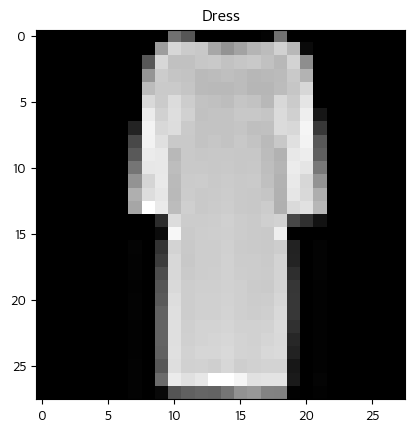

In [119]:
import random

rand_idx = random.randint(0, len(TRAIN_DATASET))
data = TRAIN_DATASET[rand_idx]

plt.imshow(data[0], cmap="gray")
plt.title(f"{CLASS_DICT[data[1]]}")
plt.show()